<h1><center>Laboratorio 4: EDA en Pandas 🐼</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

### Cuerpo Docente:

- Profesores: Pablo Badilla, Diego Cortez
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Patricio Espinoza Acuña.
- Nombre de alumno 2: Javiera Romero Orrego.


### **Link de repositorio de GitHub:** `http://....`


## Reglas:

- **Grupos de 2 personas**
- Asistencia **obligatoria** a instrucciones del lab (viernes 16.15). Luego, pueden quedarse trabajando en las salas o irse.
- **No se revisarán entregas de personas ausentes**. 
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibidas las copias. 
- Pueden usar cualquer matrial del curso que estimen conveniente.

### Objetivos principales del laboratorio

- Aplicar los paradigmas y buenas prácticas de programación vistas hasta este momento.
- Utilizar las funciones de la librería `pandas` para realizar análisis exploratorio de datos
- Aplicar principios de visualización de datos vistos en clases para mostrar patrones en los datos


El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas de `pandas`.

## Descripción del laboratorio.

### Importamos librerias utiles 😸

In [20]:
# Libreria Core del lab.

# Libreria para plotear
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import plotly.express as px
from IPython.display import Markdown, display
from scipy import stats

# Segmentación de Clientes en Tienda de Retail 🛍️

<p align="center">
  <img width=300 src="https://s1.eestatic.com/2018/04/14/social/la_jungla_-_social_299733421_73842361_854x640.jpg">
</p>

## 1.1 Cargar dataset [0.5 puntos]

Mr. Lepin Mora quien es el gerente de una cotizada tienda de retail en Europa, les solicita si pueden analizar los datos de algunas de sus tiendas.

Para esto, el área de ventas les entrega el 2 archivos: `online_retail_II.pickle` y `online_retail_I.pickle`.
- Cargue ambas fuentes y asegúrese que las columnas son del tipo correcto como en el ejemplo de df_retail_1 visualizando los datos para determinar el tipo. Para fechas, puede usar `'datetime64[ns]'`
- Combine los dataframes en uno solo. ¿Qué función debe utilizar en este caso? R: Debemos utilizar merge ya que tenemos un identificador común entre ambos datasets, "Invoice". Además utilizamos left join tomando primero al dataset retail 1 ya que si tenemos por ejemplo 5 productos con un mismo Invoice, ya que pertenecen a una misma compra, queremos que queden con la misma fecha indicada en el segundo dataset para dicho Invoice.  
- Señale las columnas que componen el dataset combinado, el tipo de variable presente en cada columna y comente que representa cada una de estas. R: todo respondido en el código.

**Respuesta:**

In [21]:
df_retail_1 = pd.read_pickle("online_retail_I.pickle")
df_retail_1 = df_retail_1.astype(
    {
        "Invoice": "category",
        "StockCode": "category",
        "Description": str,
        "Customer ID": "category",
        "Quantity": int,
        "Price": float,
        "Country": "category",
    }
)
df_retail_1.head()

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom


In [22]:
# visualización y tipos de datos del segundo dataset
df_retail_2 = pd.read_pickle("online_retail_II.pickle")
df_retail_2 = df_retail_2.astype(
    {
        "Invoice": "category",
        "InvoiceDate": "datetime64[ns]",
    }
)
df_retail_2.head()

,Invoice,InvoiceDate
0,489434,2009-12-01 07:45:00
1,489435,2009-12-01 07:46:00
2,489436,2009-12-01 09:06:00
3,489437,2009-12-01 09:08:00
4,489438,2009-12-01 09:24:00


In [23]:
# Unir ambos datasets
df_retail = df_retail_1.merge(df_retail_2, on="Invoice", how="left")
df_retail = df_retail.astype(
    {
        "Invoice": "category",  # Número de transacción
        "StockCode": "category",  # Código del producto
        "Description": str,  # Descripción del producto
        "Customer ID": "category",  # ID del cliente
        "Quantity": int,  # Cantidad de productos comprados
        "Price": float,  # Precio unitario del producto
        "Country": "category",  # País del cliente
        "InvoiceDate": "datetime64[ns]",  # Fecha y hora de la compra
    }
)

df_retail.head(10)

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,InvoiceDate
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom,2009-12-01 07:45:00
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009-12-01 07:45:00
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009-12-01 07:45:00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085.0,United Kingdom,2009-12-01 07:45:00
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom,2009-12-01 07:45:00
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,1.65,13085.0,United Kingdom,2009-12-01 07:45:00
6,489434,21871,SAVE THE PLANET MUG,24,1.25,13085.0,United Kingdom,2009-12-01 07:45:00
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,5.95,13085.0,United Kingdom,2009-12-01 07:45:00
8,489435,22350,CAT BOWL,12,2.55,13085.0,United Kingdom,2009-12-01 07:46:00
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,3.75,13085.0,United Kingdom,2009-12-01 07:46:00


## 1.2 Analisís Explotatorio de los Datos [0.5 puntos] 

En base a la primera visualización del dataset, *Don Mora* le solicita que realicen un análisis exploratorio de los datos, para esto les deberán realizar un análisis univariado y multivariado. De la revisión, ustedes deben explicar potenciales anomalías visualizadas y señalar si existe la necesidad de realizar una limpieza de datos.

Explique a que nos referimos con análisis univariable, multivariable y de datos faltantes. ¿Qué beneficios nos otorga estudiar estos datos?. Sea conciso con su respuesta y no escriba mas de 5 líneas para su respuesta.

**Respuesta a la Pregunta:**

> Un análisis univariado corresponde a estudiar las variables del dataset de manera independiente una de otra, identificando propiedades de la categoría en sí, podemos observar outliers o distribuciones de la columna en sí. Mientras que el análisis multivariado nos permite identificar comportamientos conjuntos de las variables del dataset, viendo como interactuan entre ellas. Por último el análisis de datos faltantes, tal como indica su nombre, nos permite ver qué datos faltan, esto nos puede ayudar a validar si es factible continuar trabajando con estos datos, ya sea imputando o eliminando columnas problematicas, si podría llegar a sesgar los resultados del análisis o si el problema no se puede abordar. 

### 1.2.1 Análisis Univariado [1.5 Puntos]

A continuación, se le presentan dos funciones para analizar los datos que componen un dataframe. La primera de estas es la función ``profile_serie()`` la cual recibe una serie y le entrega un análisis detallado de los datos que conforman dicha serie. 

Ejecute la funcion ``profile_serie()`` sobre cada serie para realizar un análisis univariado de estas. A continuación, comente acerca de el comportamiento de cada variable según las estadísticas descriptivas y los gráficos generados.

In [24]:
from pandas.api.types import is_datetime64_any_dtype, is_numeric_dtype, is_timedelta64_dtype


def profile_serie(serie_in, n_samples=1000, random_state=42):
    serie = serie_in.copy()

    profile = pd.Series(dtype="object")
    profile["Type"] = serie.dtype
    profile = pd.concat([profile, serie.describe()])

    # profile = pd.Series([])

    if is_numeric_dtype(serie):
        profile["Negative"] = (serie < 0).sum()
        profile["Negative (%)"] = str(round((serie < 0).sum() / len(serie) * 100, 2)) + " %"
        profile["Zeros"] = (serie == 0).sum()
        profile["Zeros (%)"] = str(round((serie == 0).sum() / len(serie) * 100, 2)) + " %"
        profile["Kurt"] = serie.kurt()
        profile["Skew"] = serie.skew()

    profile[" "] = " "  # espacio

    profile["Missing cells"] = serie.isnull().sum()
    profile["Missing cells (%)"] = str(round(serie.isnull().sum() / len(serie) * 100, 2)) + " %"
    profile["Duplicate rows"] = serie.duplicated(False).sum()
    profile["Duplicate rows (%)"] = str(round(serie.duplicated(False).sum() / len(serie) * 100, 2)) + " %"
    profile["Total size in memory"] = str(serie.memory_usage(index=True)) + " bytes"

    # profile = pd.concat([profile, description])

    profile = profile.rename(
        index={
            "count": "Number of observations",
            "mean": "Mean",
            "std": "Std",
            "min": "Min",
            "max": "Max",
            "unique": "Unique",
            "top": "Top",
            "freq": "Freq",
        }
    )
    no_outliers_fig = None

    if is_numeric_dtype(serie):
        sampled_serie = serie.sample(n_samples, random_state=random_state)
        fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name} - With Outliers")

        no_outliers = sampled_serie.loc[(np.abs(stats.zscore(sampled_serie)) < 3)]
        # zscore = https://es.wikipedia.org/wiki/Unidad_tipificada

        no_outliers_fig = px.histogram(no_outliers, marginal="box", title=f"{serie.name} - Without Outliers")

    elif is_datetime64_any_dtype(serie) or is_timedelta64_dtype(serie):
        sampled_serie = serie.sample(n_samples, random_state=random_state)
        fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name}")

    else:
        count = serie.value_counts()[0:100].reset_index().rename(columns={"count": "Count"})
        fig = px.bar(
            x=count[serie.name].astype(str),
            y=count["Count"],
            title=f"100 Most common categories of {serie.name}",
        )
    display(Markdown(f"## {serie.name} Profile"))
    display(profile)
    fig.show()

    if no_outliers_fig:
        no_outliers_fig.show()

    # return fig, profile

In [25]:
profile_serie(df_retail["Price"])
profile_serie(df_retail["Quantity"])
profile_serie(df_retail["InvoiceDate"])
profile_serie(df_retail["Country"])
profile_serie(df_retail["Description"])
profile_serie(df_retail["Customer ID"])
profile_serie(df_retail["StockCode"])
profile_serie(df_retail["Invoice"])

## Price Profile

Type                            float64
Number of observations         525461.0
Mean                           4.688834
Std                          146.126914
Min                           -53594.36
25%                                1.25
50%                                 2.1
75%                                4.21
Max                            25111.09
Negative                              3
Negative (%)                      0.0 %
Zeros                              3687
Zeros (%)                         0.7 %
Kurt                       64868.344873
Skew                        -140.768446
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   524485
Duplicate rows (%)              99.81 %
Total size in memory      4203820 bytes
dtype: object

## Quantity Profile

Type                              int64
Number of observations         525461.0
Mean                          10.337667
Std                           107.42411
Min                             -9600.0
25%                                 1.0
50%                                 3.0
75%                                10.0
Max                             19152.0
Negative                          12326
Negative (%)                     2.35 %
Zeros                                 0
Zeros (%)                         0.0 %
Kurt                        6277.666908
Skew                          36.044617
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   525122
Duplicate rows (%)              99.94 %
Total size in memory      4203820 bytes
dtype: object

## InvoiceDate Profile

...

Type                           category
Number of observations         417534.0
Unique                           4383.0
Top                             14911.0
Freq                             5710.0
                                       
Missing cells                    107927
Missing cells (%)               20.54 %
Duplicate rows                   525327
Duplicate rows (%)              99.97 %
Total size in memory      1086118 bytes
dtype: object

## StockCode Profile

Type                           category
Number of observations           525461
Unique                             4632
Top                              85123A
Freq                               3516
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   525026
Duplicate rows (%)              99.92 %
Total size in memory      1220246 bytes
dtype: object

## Invoice Profile

Type                           category
Number of observations           525461
Unique                            28816
Top                              537434
Freq                                675
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   517456
Duplicate rows (%)              98.48 %
Total size in memory      2338390 bytes
dtype: object

RECORDAR Q EL INVOICE REPRESENTA UNA TRANSACCIÓN, UN INVOICE QUE SE REPITE MUCHO ES PQ LA TRANSACCION TENIA MUCHOS PRODUCTOS

    Análisis de la n-esima serie...

### 1.2.2 Análisis Multivariado y Datos Faltantes [1 ptos]

En segundo lugar encontrará la función ``profile_df()`` que recibe un dataframe como entrada y realiza un análisis bivariado de todas las variables numéricas que conforman el dataframe, un analisis de la correlación de Pearson entre las variables numericas del dataframe y la matriz de datos faltantes.

Utilice esta función en el dataframe. Comente sobre los patrones que observa. Luego responda:
- Existen correlaciones relevantes observadas?
- Qué aspectos revelan estos gráficos acerca de la limpieza de los datos?

In [26]:
def profile_df(dataframe_in):
    df = dataframe_in.copy()

    list_type = []
    for col in list(df.columns):
        if is_numeric_dtype(df[col]) or is_datetime64_any_dtype(df[col]) or is_timedelta64_dtype(df[col]):
            list_type.append(col)

    display(Markdown("## Bivariant Analysis:"))
    for i in range(len(list_type)):
        for j in range(i + 1, len(list_type)):
            plt.scatter(df[list_type[i]], df[list_type[j]])
            plt.xlabel(list_type[i])
            plt.ylabel(list_type[j])
            plt.title(f"{list_type[i]} v/s {list_type[j]}")
            plt.show()

    display(Markdown("## Correlation:"))
    fig_corr = px.imshow(df[list_type].corr())
    fig_corr.show()

    display(Markdown("## Missing Matrix:"))
    fig, ax = plt.subplots(figsize=[15, 10])
    msno.matrix(df, ax=ax, sparkline=False)

## Bivariant Analysis:

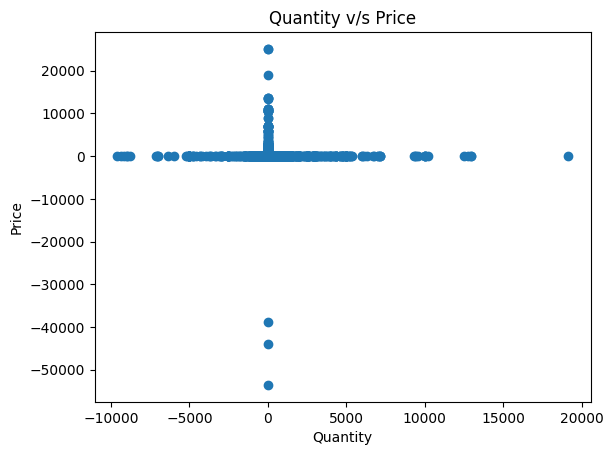

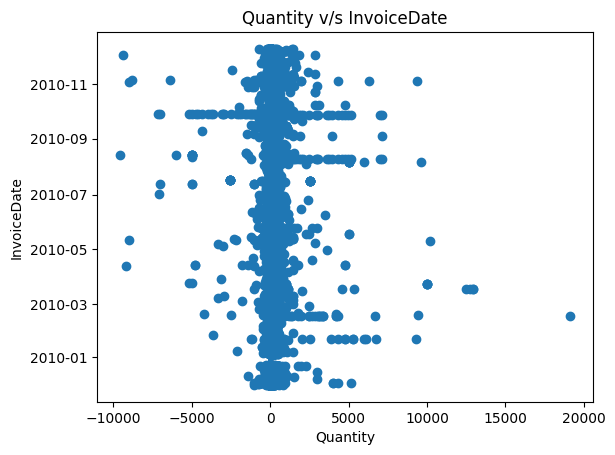

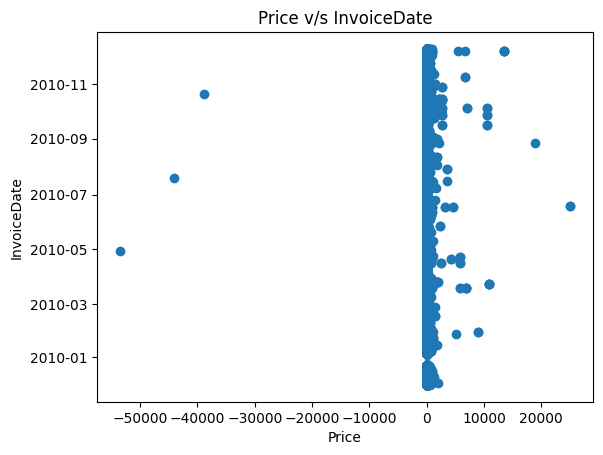

## Correlation:

## Missing Matrix:

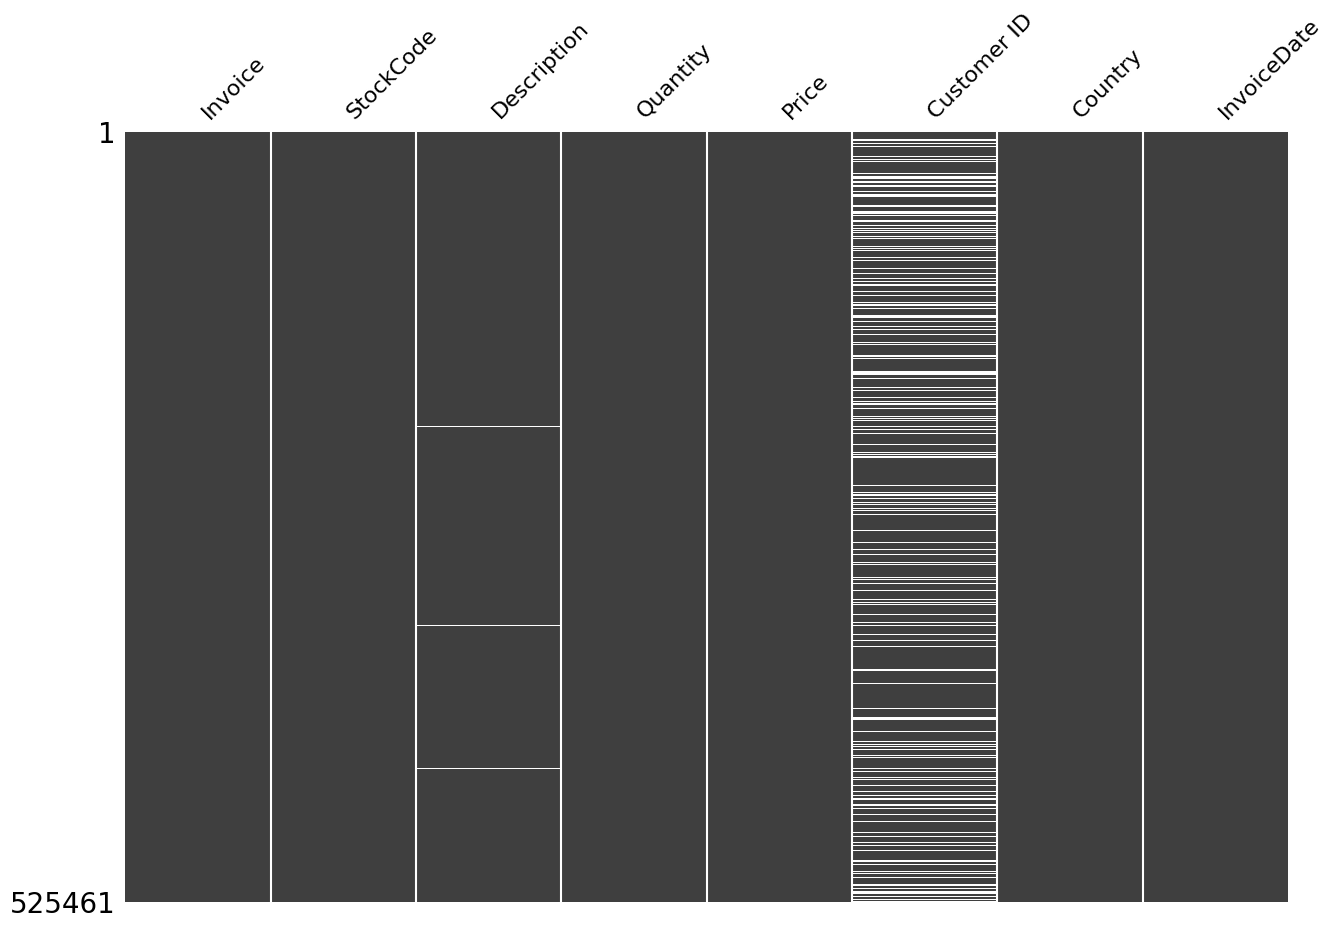

In [27]:
profile_df(df_retail)

### 1.2.3 Limpieza de Datos [1 pto]

Como pudo ver en las secciones anteriores, los datos presentan valores erroneos, es por esto que se le solicita que realice una función que permita limpiar el dataset. Realice esta función en base observaciones propias y considere como **imposible tener cantidades negativas** en las ventas. Investigue sobre métodos para eliminar outliers usando pandas

Una vez realizada la función, realice nuevamente el análisis exploratorio y comente las principales diferencias.

**Respuesta:**

### 1.2.4 Obtención de TOPs [0.75 ptos]

Sin considerar los comentarios realizados en la sección 1.2 , *Don Mora* les pide obtener el **Top de 30 productos que generan más ganancias** para la tienda de retail. Deben considerar todo el registro temporal presente en el dataset y entregar la información en un gráfico de barras de los ingresos/cantidades v/s el nombre de los productos (Utilice `plotly`). ¿Los artículos más vendidos son los mismos que generan más ganancias?, Comente los resultados obtenidos.

**Resultados:**

### 1.2.5 Visualización del registro temporal [0,75 ptos]

El dueño del retail en su afán por saber más sobre los datos de su firma les solicita que grafiquen las ventas respecto al tiempo. Con esto les aclara que durante el día tienen muchas variaciones en sus ventas, por lo que les recomienda que consideren el registro temporal como `año-mes-día`. ¿Es posible observar datos extraños?, Comente lo que observa del gráfico.

In [28]:
def plot_ventas(dataframe):
    pass

# Conclusión
Eso ha sido todo para el lab de hoy, recuerden que el laboratorio tiene un plazo de entrega de una semana. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

![Gracias Totales!](https://i.pinimg.com/originals/65/ae/27/65ae270df87c3c4adcea997e48f60852.gif "bruno")


<br>
<center>
<img src="https://i.kym-cdn.com/photos/images/original/001/194/195/b18.png" width=100 height=50 />
</center>
<br>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=87110296-876e-426f-b91d-aaf681223468' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>